In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium 
import os 

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6) #12x6 chart size

In [5]:
import os
# Look inside the notebooks folder
print(os.listdir('/Users/tahminasahar/earthquake-risk-afghanistan'))


['.DS_Store', 'requirements.txt', 'models', 'docs', 'README.md', 'dashboard', '.gitignore', '.ipynb_checkpoints', 'venv', '.git', 'data', 'notebooks', 'src']


In [6]:
df = pd.read_csv('../data/usgs_afghanistan_raw.csv')
df['time'] = pd.to_datetime(df['time'])

df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

print(f"Total Earthquakes loaded: {len(df)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nAny missing values:?")
print(df[['mag', 'depth', 'latitude', 'longitude']].isnull().sum())

Total Earthquakes loaded: 8250

Data types:
time               datetime64[us, UTC]
latitude                       float64
longitude                      float64
depth                          float64
mag                            float64
magType                            str
nst                            float64
gap                            float64
dmin                           float64
rms                            float64
net                                str
id                                 str
updated                            str
place                              str
type                               str
horizontalError                float64
depthError                     float64
magError                       float64
magNst                         float64
status                             str
locationSource                     str
magSource                          str
year                             int32
month                            int32
dtype: object

Any m

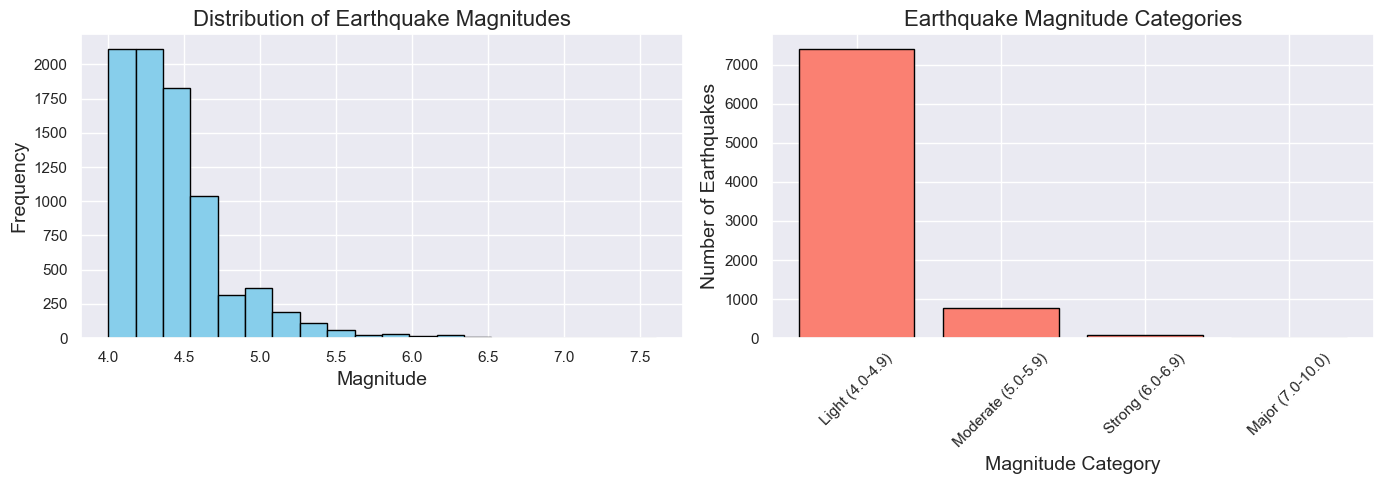

Magnitude distribution plot saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 


axes[0].hist(df['mag'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Earthquake Magnitudes', fontsize = 16)
axes[0].set_xlabel('Magnitude', fontsize = 14)
axes[0].set_ylabel('Frequency', fontsize = 14)

bins = [4.0, 4.9, 5.9, 6.9, 10.0]
labels = ['Light (4.0-4.9)', 'Moderate (5.0-5.9)', 'Strong (6.0-6.9)', 'Major (7.0-10.0)']
df['magnitude_category'] = pd.cut(df['mag'], bins = bins, labels = labels, right = False)

category_counts = df['magnitude_category'].value_counts().sort_index()
axes[1].bar(category_counts.index, category_counts.values, color='salmon', edgecolor='black')
axes[1].set_title('Earthquake Magnitude Categories', fontsize = 16)
axes[1].set_xlabel('Magnitude Category', fontsize = 14)
axes[1].set_ylabel('Number of Earthquakes', fontsize = 14)
axes[1].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.savefig('/Users/tahminasahar/earthquake-risk-afghanistan/data/magnitude_distribution.png', dpi = 150)
plt.show()
print("Magnitude distribution plot saved.")

# Research paper
Most earthquakes in Afghanistan are Light (4.0–4.9) - this is normal for any seismically active region. The histogram leaning heavily toward smaller magnitudes follows what's called the Gutenberg-Richter Law - one of the most fundamental principles in seismology. It states that for every large earthquake, there are many more smaller ones. 

"Analysis of 8,250 seismic events recorded between 1990–2024 reveals that light magnitude earthquakes (4.0–4.9) constitute the majority of seismic activity in the Afghanistan region, consistent with the Gutenberg-Richter frequency-magnitude relationship."




# Earthquake frequency over time

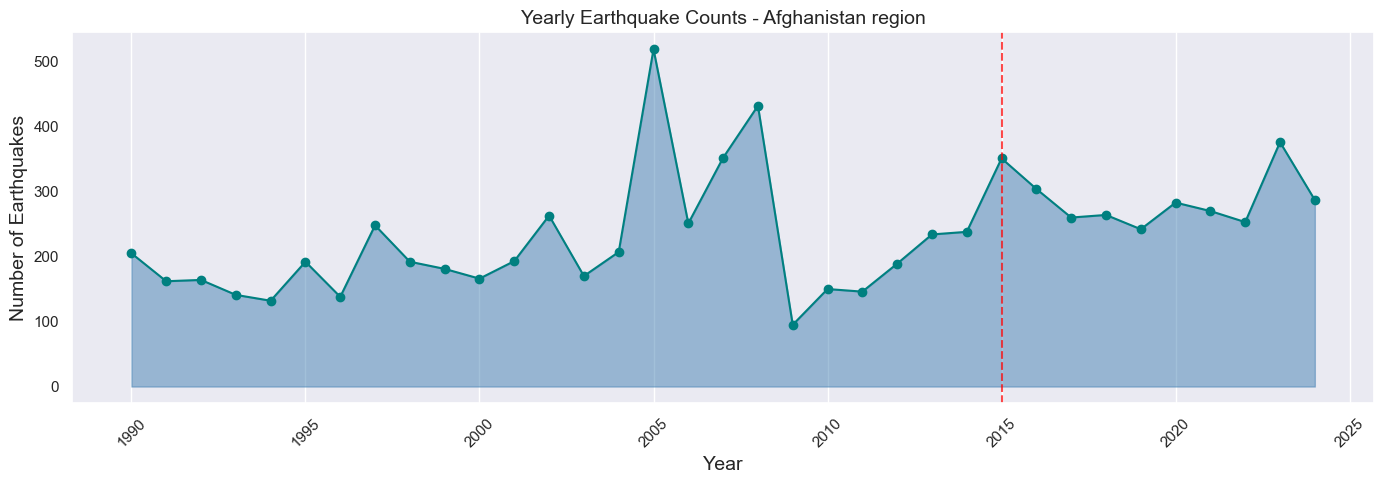

Most earthquakes occurred in 2005 with 519 events.
Least earthquakes occurred in 2009 with 95 events.
Average earthquakes per year: 236


In [9]:
yearly = df.groupby('year').size().reset_index(name='count')


plt.figure(figsize=(14, 5))
plt.plot(yearly['year'], yearly['count'], marker='o', color='teal')
plt.fill_between(yearly['year'], yearly['count'], color='steelblue', alpha=0.5)
plt.title('Yearly Earthquake Counts - Afghanistan region', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)
plt.axvline(x=2015, color='red', linestyle='--', label='2015 Hindu Kush Earthquake', alpha=0.7)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/Users/tahminasahar/earthquake-risk-afghanistan/data/yearly_earthquake_counts.png', dpi=150)
plt.show()
print(f"Most earthquakes occurred in {yearly.loc[yearly['count'].idxmax(), 'year']} with {yearly['count'].max()} events.")
print(f"Least earthquakes occurred in {yearly.loc[yearly['count'].idxmin(), 'year']} with {yearly['count'].min()} events.")
print(f"Average earthquakes per year: {yearly['count'].mean():.0f}")

# Research 
Temporal analysis reveals 2005 as the most seismically active year with 236 recorded events, coinciding with the devastating Kashmir earthquake and its subsequent aftershock sequence, underscoring the region's sustained seismic hazard.

# Map that is centered on Afghanistan 

In [10]:
afghanistan_map = folium.Map(
    location=[33.9391, 65.7100], 
    zoom_start=6, 
    tiles='CartoDB positron'
)

def get_color(mag):
    if mag >= 7.0:
        return 'red'
    elif mag >= 5.0:
        return 'orange'
    elif mag >= 3.0:
        return 'yellow'
    else:
        return 'green'

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['mag'] * 2,
        color=get_color(row['mag']),
        fill=True,
        fill_color=get_color(row['mag']),
        fill_opacity=0.6,
        popup=f"Magnitude: {row['mag']}"
    ).add_to(afghanistan_map)
afghanistan_map.save('/Users/tahminasahar/earthquake-risk-afghanistan/data/afghanistan_earthquake_map.html')
print("Map has been saved successfully.")


Map has been saved successfully.


# Depth vs Magnitude Analysis 

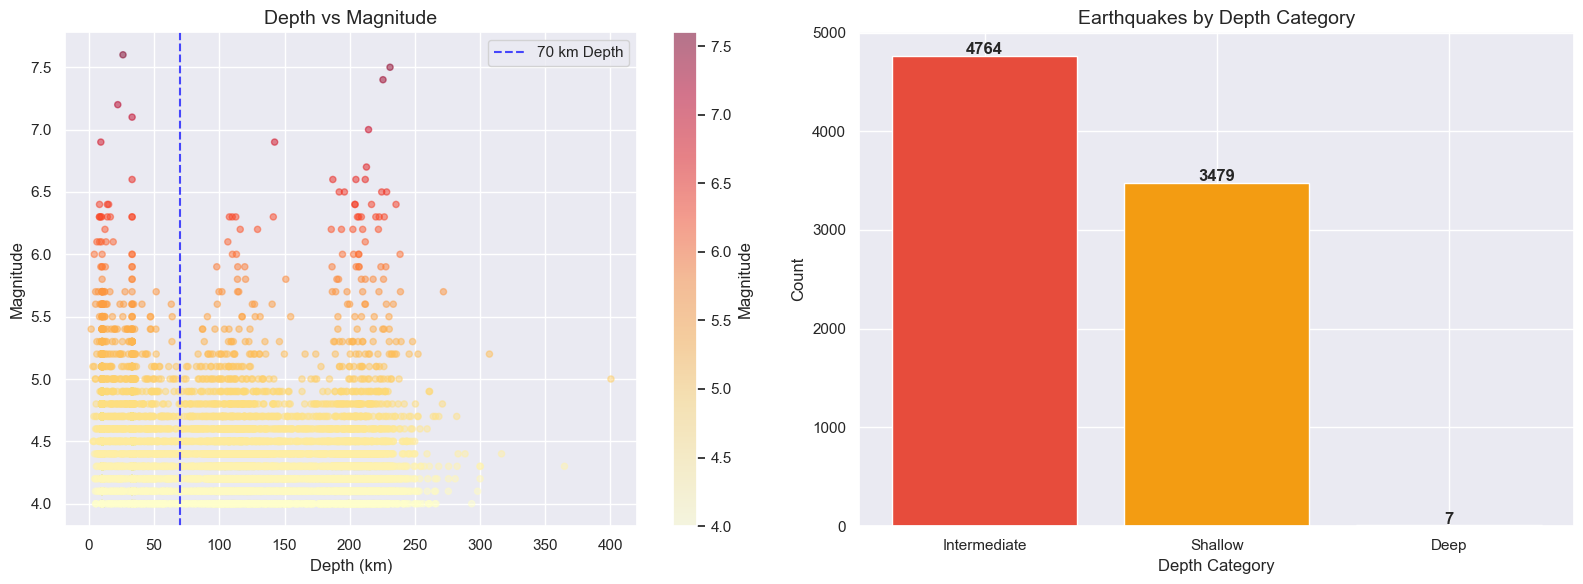

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(
    df['depth'], 
    df['mag'],
    c=df['mag'],
    cmap='YlOrRd',
    alpha=0.5,
    s=20
)
plt.colorbar(scatter, ax=axes[0], label='Magnitude')
axes[0].set_title('Depth vs Magnitude', fontsize=14)
axes[0].set_xlabel('Depth (km)', fontsize=12)
axes[0].set_ylabel('Magnitude', fontsize=12)
axes[0].axvline(x=70, color='blue', linestyle='--', label='70 km Depth', alpha=0.7)
axes[0].legend()


depth_bins = [0, 70, 300, 800]
depth_labels = ['Shallow', 'Intermediate', 'Deep']

df['depth_category'] = pd.cut(df['depth'], bins=depth_bins, labels=depth_labels, right=False)


depth_counts = df['depth_category'].value_counts()
# Count how many earthquakes are in each category


# Draw the bar chart
colors = ['#e74c3c', '#f39c12', '#3498db']  # red, orange, blue
axes[1].bar(depth_counts.index, depth_counts.values, color=colors)
axes[1].set_title('Earthquakes by Depth Category', fontsize=14)
axes[1].set_xlabel('Depth Category')
axes[1].set_ylabel('Count')

# Add the exact number on top of each bar
for i, (val, label) in enumerate(zip(depth_counts.values, depth_counts.index)):
    axes[1].text(i, val + 20, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/tahminasahar/earthquake-risk-afghanistan/data/depth_analysis.png', dpi=150)
plt.show()




"Which specific named locations get hit by earthquakes most often?"

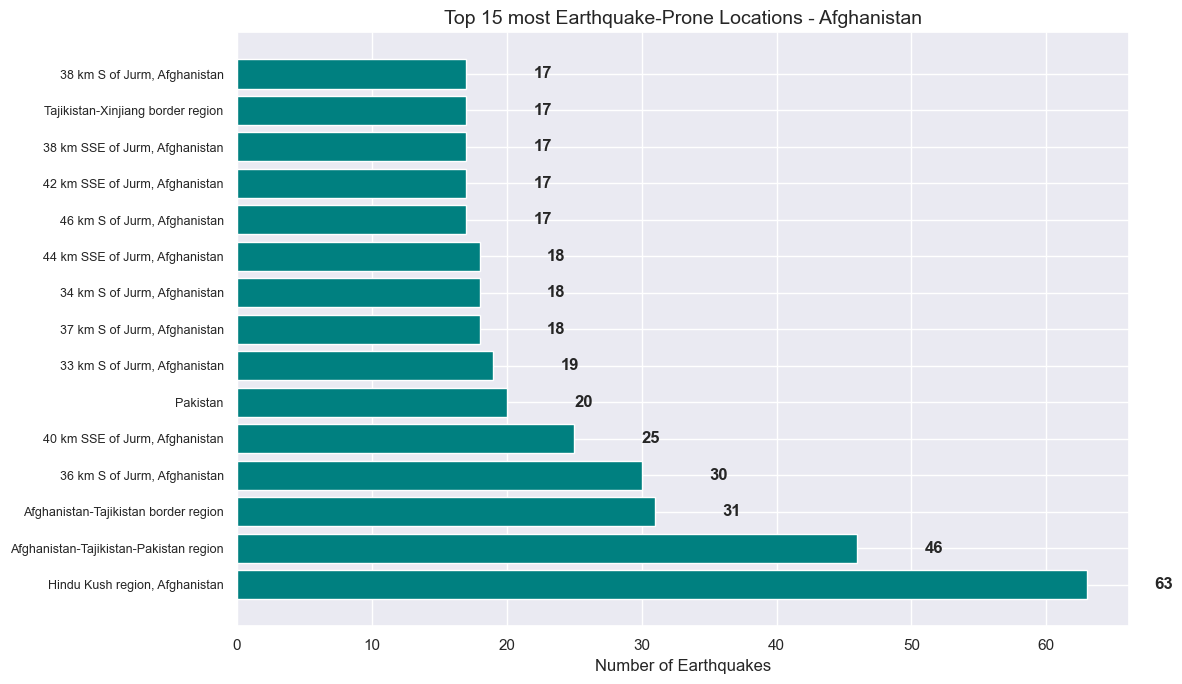

Top 15 most Earthquake-Prone Locations - Afghanistan
Hindu Kush region, Afghanistan: 63 earthquakes
Afghanistan-Tajikistan-Pakistan region: 46 earthquakes
Afghanistan-Tajikistan border region: 31 earthquakes
36 km S of Jurm, Afghanistan: 30 earthquakes
40 km SSE of Jurm, Afghanistan: 25 earthquakes
Pakistan: 20 earthquakes
33 km S of Jurm, Afghanistan: 19 earthquakes
37 km S of Jurm, Afghanistan: 18 earthquakes
34 km S of Jurm, Afghanistan: 18 earthquakes
44 km SSE of Jurm, Afghanistan: 18 earthquakes
46 km S of Jurm, Afghanistan: 17 earthquakes
42 km SSE of Jurm, Afghanistan: 17 earthquakes
38 km SSE of Jurm, Afghanistan: 17 earthquakes
Tajikistan-Xinjiang border region: 17 earthquakes
38 km S of Jurm, Afghanistan: 17 earthquakes


In [13]:
top_locations = df['place'].value_counts().head(15)

plt.figure(figsize=(12, 7))

bars = plt.barh(top_locations.index, top_locations.values, color='teal')

plt.yticks(range(len(top_locations)), top_locations.index, fontsize=9)
plt.title('Top 15 most Earthquake-Prone Locations - Afghanistan', fontsize=14)
plt.xlabel('Number of Earthquakes', fontsize=12)

for bar, val in zip(bars, top_locations.values):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/tahminasahar/earthquake-risk-afghanistan/data/top_locations.png')
plt.show()

print("Top 15 most Earthquake-Prone Locations - Afghanistan")
for location, count in zip(top_locations.index, top_locations.values):
    print(f"{location}: {count} earthquakes")

In [14]:
import json

summary = {
    'total_earthquakes': len(df),
    'date_range': f"{df['time'].min().date()} to {df['time'].max().date()}",
    'magnitude_range': f"{df['mag'].min()} to {df['mag'].max()}",
    'average_magnitude': round(df['mag'].mean(), 2),
    'most_active_year': int(df.groupby('year').size().idxmax()),
    'average_per_year': round(df.groupby('year').size().mean(), 0),
    'shallow_pct': round(len(df[df['depth'] < 70])/len(df)*100, 1),
    'top_location': df['place'].value_counts().index[0]
}

print("=" * 50)
print("DATASET SUMMARY — FOR RESEARCH PAPER")
print("=" * 50)
for key, value in summary.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

with open('/Users/tahminasahar/earthquake-risk-afghanistan/data/summary_stats.json', 'w') as f:
    json.dump(summary, f, indent=4)
print("\n✅ Summary stats saved to data/summary_stats.json")

DATASET SUMMARY — FOR RESEARCH PAPER
  Total Earthquakes: 8250
  Date Range: 1990-01-05 to 2024-12-30
  Magnitude Range: 4.0 to 7.6
  Average Magnitude: 4.42
  Most Active Year: 2005
  Average Per Year: 236.0
  Shallow Pct: 42.2
  Top Location: Hindu Kush region, Afghanistan

✅ Summary stats saved to data/summary_stats.json
